This file contains:
- Fig. 9
- Fig. 10
- Fig. 11
- Fig. 12
- Table 5

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import helper

from pathlib import Path

Loading library list...
Done


## Save Plots and Tables

In [34]:
# Save plots
save_plt = False

# Save tables
save_table = False

## Import Options Data, Risk-Free Data, and CRSP Data

In [3]:
# Define ticker symbols to be analyzed
tickers_array = ['APA', 'COP', 'CVX', 'DVN', 'EOG', 'HAL', 'MRO', 'OXY', 'VLO', 'XOM']

# Define time range
start_year = 2005
end_year   = 2022

# Upload Fama-French daily risk-free rate
ff_daily = helper.rf_data(start_year, end_year)

# Upload CRSP data as a dictionary
ret_tickers = helper.crsp_data(tickers_array, start_year, end_year)
# Get one single dataframe from the dictionary
df_tickers  = pd.concat(ret_tickers, ignore_index=True)

# Get dividends data
ret_div = helper.crsp_dividends(tickers_array, start_year, end_year)

# Set list to store options data
all_options = []

# Run loop to get options data
for year in range(start_year, end_year + 1):
    print(f'Processing data for {year}')
    options = helper.options_data(year, min_option_vol=1)
    options = options[options['ticker'].isin(tickers_array)]
    all_options.append(options)

# Set options dataframe
options_df = pd.concat(all_options, ignore_index=True)

Processing data for 2005
Processing data for 2006
Processing data for 2007
Processing data for 2008
Processing data for 2009
Processing data for 2010
Processing data for 2011
Processing data for 2012
Processing data for 2013
Processing data for 2014
Processing data for 2015
Processing data for 2016
Processing data for 2017
Processing data for 2018
Processing data for 2019
Processing data for 2020
Processing data for 2021
Processing data for 2022


## Filter Data

In [4]:
# Set list to store filtered dataframe
opt = []

# Run loop to filter for time-to-maturity, minimum # of strikes, and arbitrage-free options
for t in tickers_array:
    df = helper.filter_data(options_df, t, min_maturity=7, max_maturity=365, min_strikes=5)
    df = pd.merge(df, ff_daily[["date", "rf"]], on="date") # Merge filtered dataframe with risk-free rate
    opt.append(df)

# Set dataframe
opt_df = pd.concat(opt, ignore_index=True)

# Filter out options where bid > ask
opt_df = opt_df[opt_df['best_bid'] <= opt_df['best_offer']].copy()

# Filter for only standard option contracts
opt_df = opt_df[opt_df['ss_flag'] == '0'].copy()

# Filter for open_interest > 0
opt_df = opt_df[opt_df['open_interest'] > 0].copy()

# Filter for minimum prices
opt_df = opt_df[opt_df['opt_price'] >= 0.375].copy()

# Filter by moneyness
opt_df = opt_df[(opt_df['moneyness'] >= 0.8) & (opt_df['moneyness'] <= 1.2)].copy()

# Keep only desired variables
opt_df = opt_df[['date', 'ticker', 'cp_flag', 'optionid', 'strike_price', 'opt_price', 
                 'maturity_days', 'spot_price', 'moneyness', 'log_moneyness', 'rf']].copy()

# Create year column
opt_df['year'] = opt_df['date'].dt.year

# Create %moneyness column
opt_df['%moneyness'] = opt_df['moneyness'] - 1

# Organize dataframe for calls and puts
calls_df = opt_df[opt_df['cp_flag'] == 'C'].copy()
puts_df  = opt_df[opt_df['cp_flag'] == 'P'].copy()

# Get constant dividend yield
div_yield = helper.const_div_yield(ret_div, df_tickers)

# Merge constant dividend yield to options dataframe
calls_df = pd.merge(calls_df, div_yield[['ticker', 'year', 'q']], on=['ticker', 'year'])

## Estimate Jump-Diffusion Modeled Prices

In [5]:
# Set rolling window
rolling_window = 3

# Set indexed dataframe
calls_idx = calls_df.set_index(['ticker', 'year']).sort_index()

# Get starting values
sv = helper.starting_values(df_tickers, tickers_array, rolling_window=rolling_window)
sv_idx = sv.set_index(['ticker', 'start_year', 'end_year']).sort_index()

# Define bounds (constant)
lb, ub = helper.default_bounds(['sigma', 'lam', 'mu', 'delta'])

# Set lists to store results
param_list_merton, stats_list_merton = [], []
prices_m = {}

# Run loop for estimating prices per ticker
for t in tickers_array:
    # Set years list from the dataframe
    years = calls_idx.loc[t].index.unique().to_list()

    # Run loop for rolling window
    for i in range (0, len(years), rolling_window):
        # Set start of rolling window
        start = years[i]
        # Set end of rolling window
        end   = start + rolling_window - 1
        
        # Set options within the rollinw window
        try:
            window_df = calls_idx.loc[(t, slice(start, end)), :].reset_index()
        except KeyError:
            continue
        # Set starting values within the rolling window
        try:
            sv_row = sv_idx.loc[(t, start, end)]
        except KeyError:
            continue

        # Set parameters starting values
        sigma0 = sv_row['imp_vol']
        lam0   = sv_row['jump_arrival']
        mu0    = sv_row['jump_mean']
        delta0 = sv_row['jump_vol']

        x0 = [sigma0, lam0, mu0, delta0]

        # Prepare market inputs
        S, K, tau, r, q, C_mkt = helper.prepare_inputs(window_df)

        # Estimate parameters
        theta, res, free_keys = helper.calibrate_merton(
            S=S, K=K, tau=tau, r=r, q=q, C_mkt=C_mkt,
            x0=x0,
            bounds=(lb, ub),
            n_max=10,
            method='trf',
            tol=1e-10,
            max_nfev=1500,
            verbose=0
        )
        # Store parameters by ticker and rolling window
        param = {
                'ticker'    : t,
                'start_year': start,
                'end_year'  : end,
                'sigma'     : theta['sigma'],
                'lam'       : theta['lam'],
                'mu'        : theta['mu'],
                'delta'     : theta['delta']
            }

        # Estimate jump-diffusion prices
        m_price = helper.merton_call_vec(S, K, tau, r, q, theta['sigma'], theta['lam'], 
                                               theta['mu'], theta['delta'], n_max=10)
        # Store modeled prices in the dataframe
        window_df['C_model'] = m_price
        # Get error column
        window_df['error']   = window_df["opt_price"] - window_df["C_model"]
        # Get %error column in percetage points
        window_df['%error']  = (window_df["error"] / window_df["opt_price"]) * 100

        # Get RMSE
        rmse = np.sqrt(np.mean(window_df['error']**2))
        # Get normalized RMSE by mean
        nrmse_mean = rmse / np.mean(C_mkt)
        # Get normalized RMSE by std
        nrmse_std  = rmse / np.std(C_mkt, ddof=1)
        # Store RMSE stats by ticker and rolling window
        stats = {
            'ticker'     : t,
            'start_year' : start,
            'end_year'   : end,
            'n_obs'      : len(window_df),
            'rmse'       : rmse,
            'nrmse_mean' : nrmse_mean,
            'nrmse_std' :  nrmse_std
        }

        # Store estimated parameters
        param_list_merton.append(param)
        # Store stats
        stats_list_merton.append(stats)
        # Store modeled prices
        prices_m[(t, start, end)] = window_df

# Get estimated parameters dataframe
param_m_df = pd.DataFrame(param_list_merton)
# Get stats dataframe
stats_m_df = pd.DataFrame(stats_list_merton)
# Get modeled prices dataframe
price_m_df = (
    pd.concat({k: df.drop(columns=["ticker"]) for k, df in prices_m.items()},
              names=["ticker", "start_year", "end_year"])
      .reset_index(level=[0, 1, 2])
      .reset_index(drop=True)
)

## Estimate Black-Scholes Modeled Prices

In [6]:
# Set rolling window
rolling_window = 3

# Set indexed dataframe
calls_idx = calls_df.set_index(['ticker', 'year']).sort_index()

# Get starting values
sv = helper.starting_values(df_tickers, tickers_array, rolling_window=rolling_window)
sv_idx = sv.set_index(['ticker', 'start_year', 'end_year']).sort_index()

# Define bounds (constant)
lb, ub = helper.default_bounds(['sigma'])

# Set lists to store results
param_list_bs, stats_list_bs = [], []
price_b = {}

# Run loop for estimating prices per ticker
for t in tickers_array:
    # Set years list from the dataframe
    years = calls_idx.loc[t].index.unique().to_list()
    
    # Run loop for rolling window
    for i in range (0, len(years), rolling_window):
        # Set start of rolling window
        start = years[i]
        # Set end of rolling window
        end   = start + rolling_window - 1
        
        # Set options within the rollinw window
        try:
            window_df = calls_idx.loc[(t, slice(start, end)), :].reset_index()
        except KeyError:
            continue
        # Set starting values within the rollinw window 
        try:
            sv_row = sv_idx.loc[(t, start, end)]
        except KeyError:
            continue
        
        # Set jump parameters to zero
        fixed = {
        'lam': 0,
        'mu':   0,   
        'delta': 0    
        }
        
        # Get starting value for sigma
        sigma0 = sv_row['imp_vol']
        x0 = [sigma0]
        
        # Prepare market inputs
        S, K, tau, r, q, C_mkt = helper.prepare_inputs(window_df)
        
        # Estimate sigma
        theta, res, free_keys = helper.calibrate_merton(
            S=S, K=K, tau=tau, r=r, q=q, C_mkt=C_mkt,
            fixed=fixed,
            x0=x0,
            bounds=(lb, ub),
            n_max=10,
            method='trf',
            tol=1e-10,
            max_nfev=1500,
            verbose=0
        )
        # Store sigma by ticker and rolling window
        param = {
                'ticker'    : t,
                'start_year': start,
                'end_year'  : end,
                'sigma'     : theta['sigma'],
                'lam'       : theta['lam'],
                'mu'        : theta['mu'],
                'delta'     : theta['delta']
            }
        
        # Estimate Black-Scholes prices
        m_price = helper.merton_call_vec(S, K, tau, r, q, theta['sigma'], theta['lam'], 
                                               theta['mu'], theta['delta'], n_max=10)
        # Store modeled prices in the dataframe
        window_df['C_model'] = m_price
        # Get error column (option market price - modeled price)
        window_df['error']   = window_df["opt_price"] - window_df["C_model"]
        # Get %error column in percentage points
        window_df['%error']  = (window_df["error"] / window_df["opt_price"]) * 100
        
        # Get RMSE
        rmse = np.sqrt(np.mean(window_df['error']**2))
        # Get normalized RMSE by mean
        nrmse_mean = rmse / np.mean(C_mkt)
        # Get normalized RMSE by std
        nrmse_std  = rmse / np.std(C_mkt, ddof=1)
        # Store RMSE stats by ticker and rolling window
        stats = {
            'ticker'     : t,
            'start_year' : start,
            'end_year'   : end,
            'n_obs'      : len(window_df),
            'rmse'       : rmse,
            'nrmse_mean' : nrmse_mean,
            'nrmse_std' :  nrmse_std
        }
        
        # Store estimated parameters
        param_list_bs.append(param)
        # Store stats
        stats_list_bs.append(stats)
        # Store Black-Scholes prices
        price_b[(t, start, end)] = window_df

# Get estimated parameters dataframe
param_b_df = pd.DataFrame(param_list_bs)
# Get stats dataframe
stats_b_df = pd.DataFrame(stats_list_bs)
# Get estimated prices dataframe
price_b_df = (
    pd.concat({k: df.drop(columns=["ticker"]) for k, df in price_b.items()},
              names=["ticker", "start_year", "end_year"])
      .reset_index(level=[0, 1, 2])
      .reset_index(drop=True)
)

## Observe Starting Values and Estimated Parameters (Table 5)

In [7]:
# Round starting values
sv[['imp_vol', 'jump_arrival', 'jump_mean', 'jump_vol']] = sv[['imp_vol', 'jump_arrival', 'jump_mean', 'jump_vol']].round(8)

# Copy jump-diffusion parameters dataframe
param_m_summary = param_m_df.copy()

# Set window column
param_m_summary["window"] = (param_m_summary["start_year"].astype(str) + "-" + param_m_summary["end_year"].astype(str))

# Drop unnecessary columns
param_m_summary = param_m_summary.drop(columns=["start_year", "end_year"])

# Round parameters
param_m_summary[["sigma", "lam", "mu", "delta"]] = param_m_summary[["sigma", "lam", "mu", "delta"]].round(6)

# Copy Black-Scholes parameters dataframe
param_b_summary = param_b_df.copy()

# Set window column
param_b_summary["window"] = (param_b_summary["start_year"].astype(str) + "-" + param_b_summary["end_year"].astype(str))

# Drop unnecessary columns
param_b_summary = param_b_summary.drop(columns=["start_year", "end_year"])

# Round parameters
param_b_summary[["sigma", "lam", "mu", "delta"]] = param_b_summary[["sigma", "lam", "mu", "delta"]].round(6)

# Save if required
if save_table:
    # Save starting values as a csv file
    sv.to_csv("start_values.csv", index=False)
    # Save BS parameters as a csv file
    param_b_summary.to_csv("bs_params.csv", index=False)
    # Save Merton parameters as a csv file
    param_m_summary.to_csv("merton_params.csv", index=False)

## Plot Normalized RMSE Time Series for Both Models and Relative Performance (Fig.9)

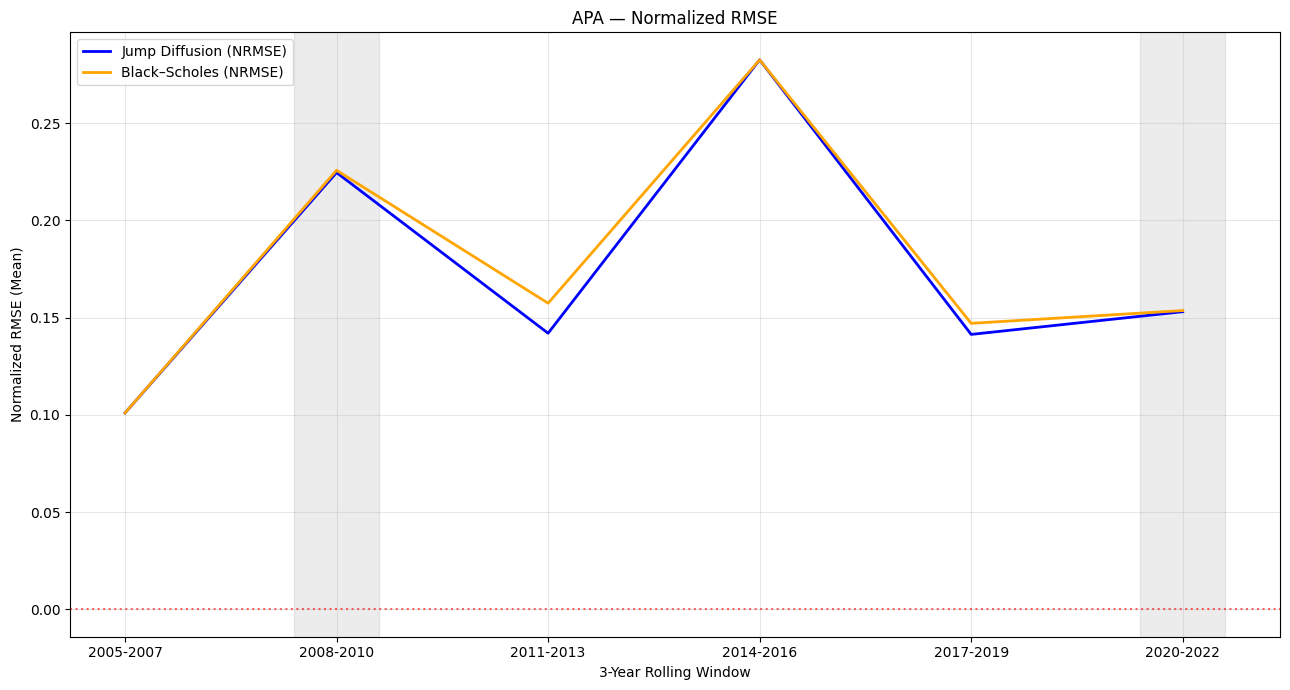

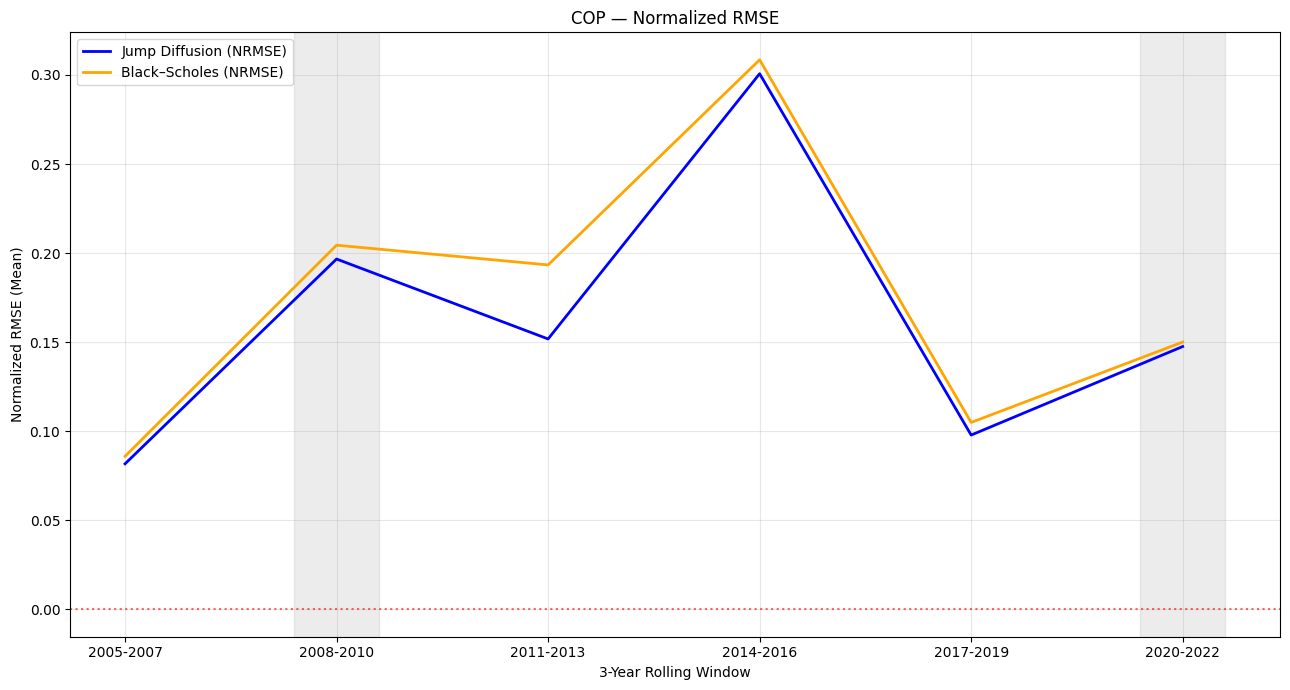

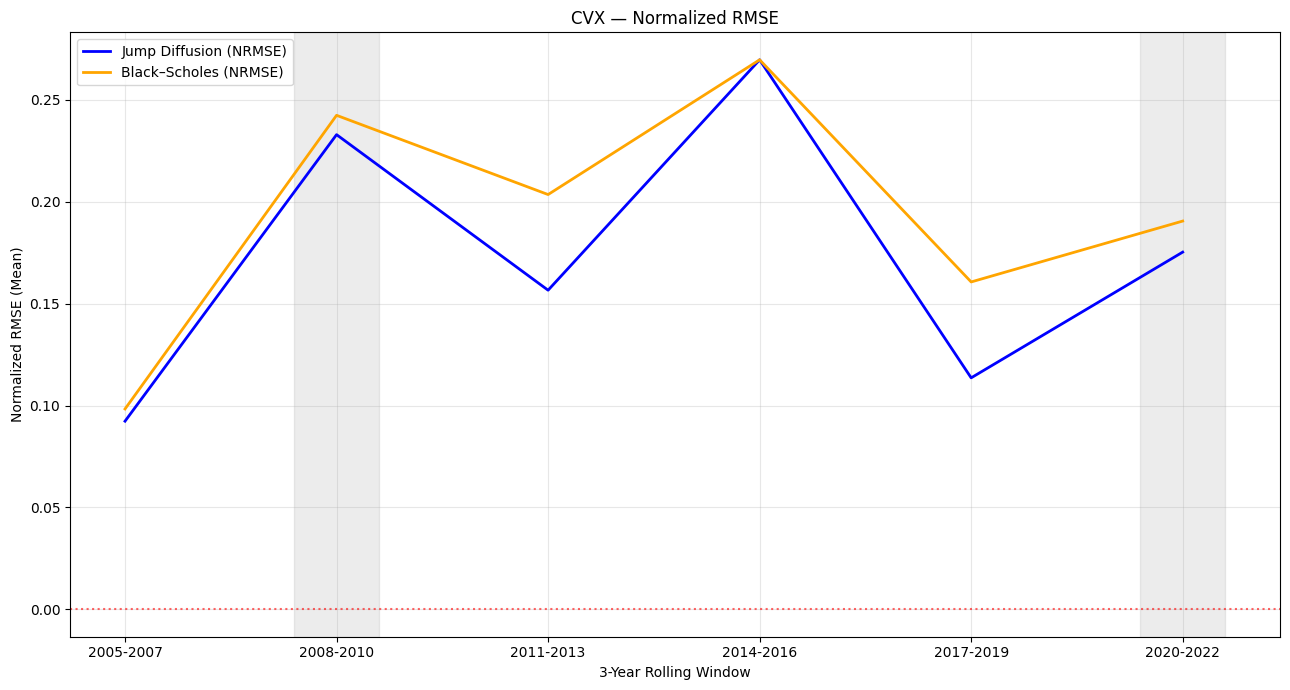

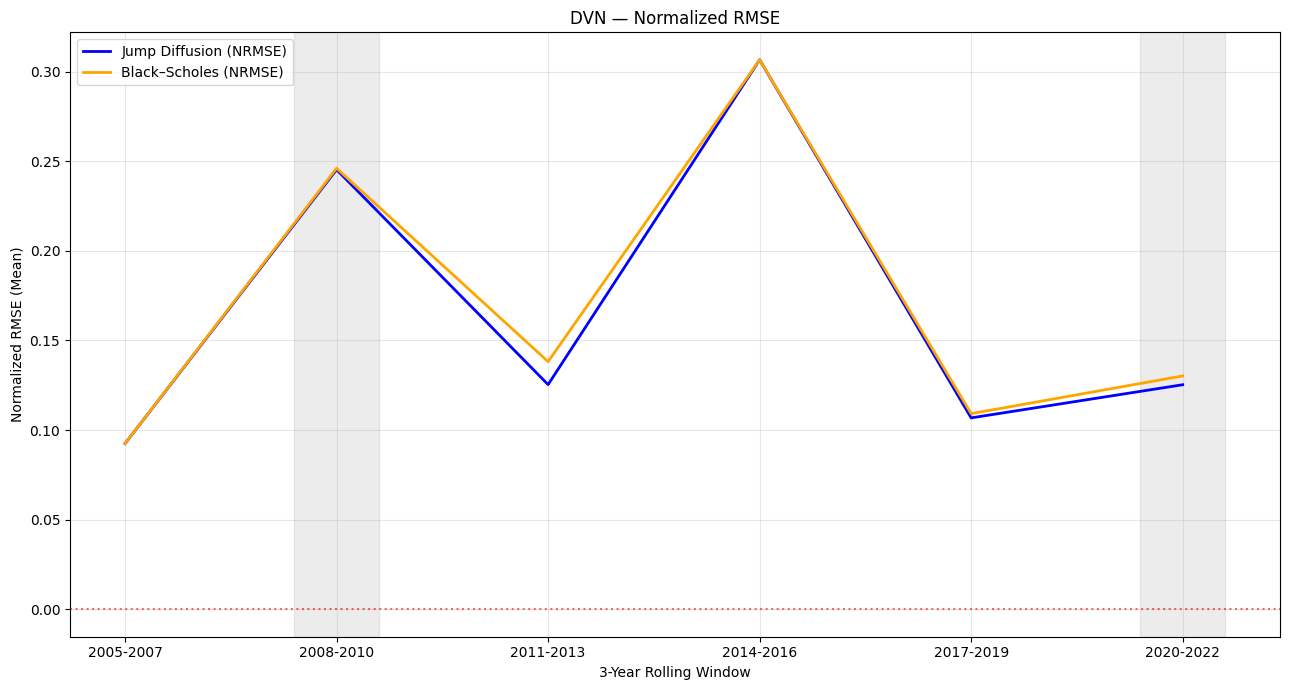

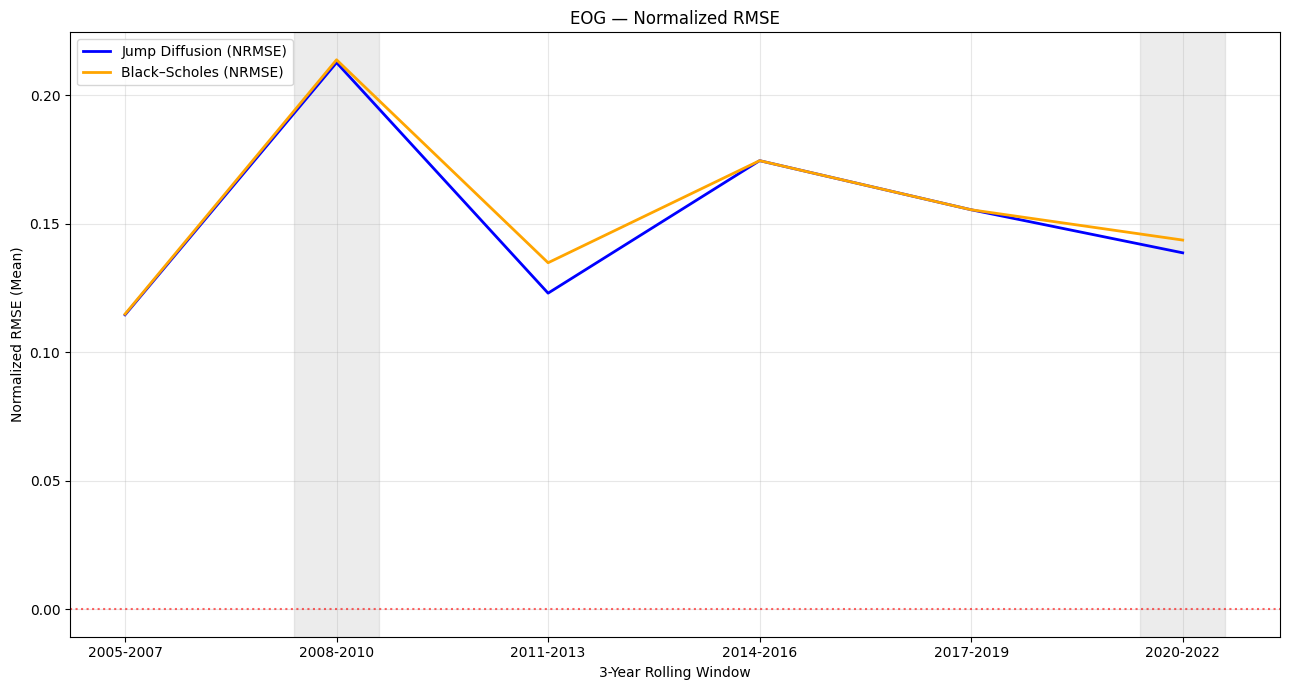

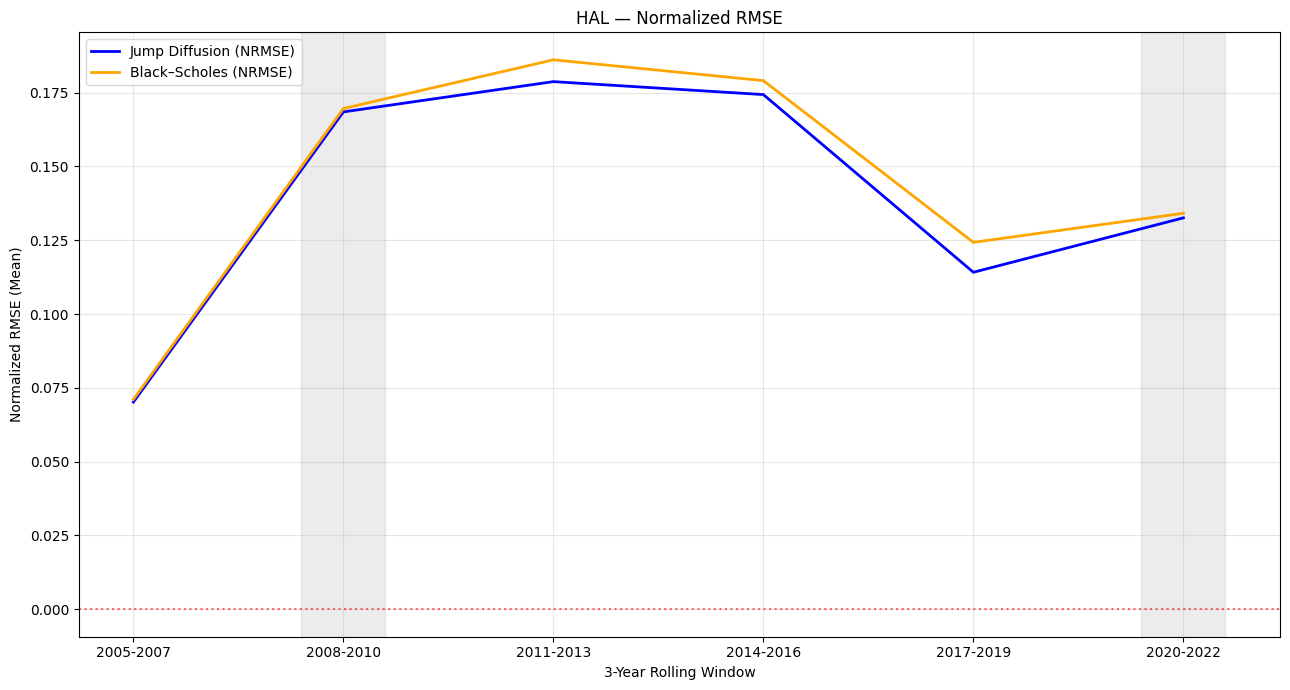

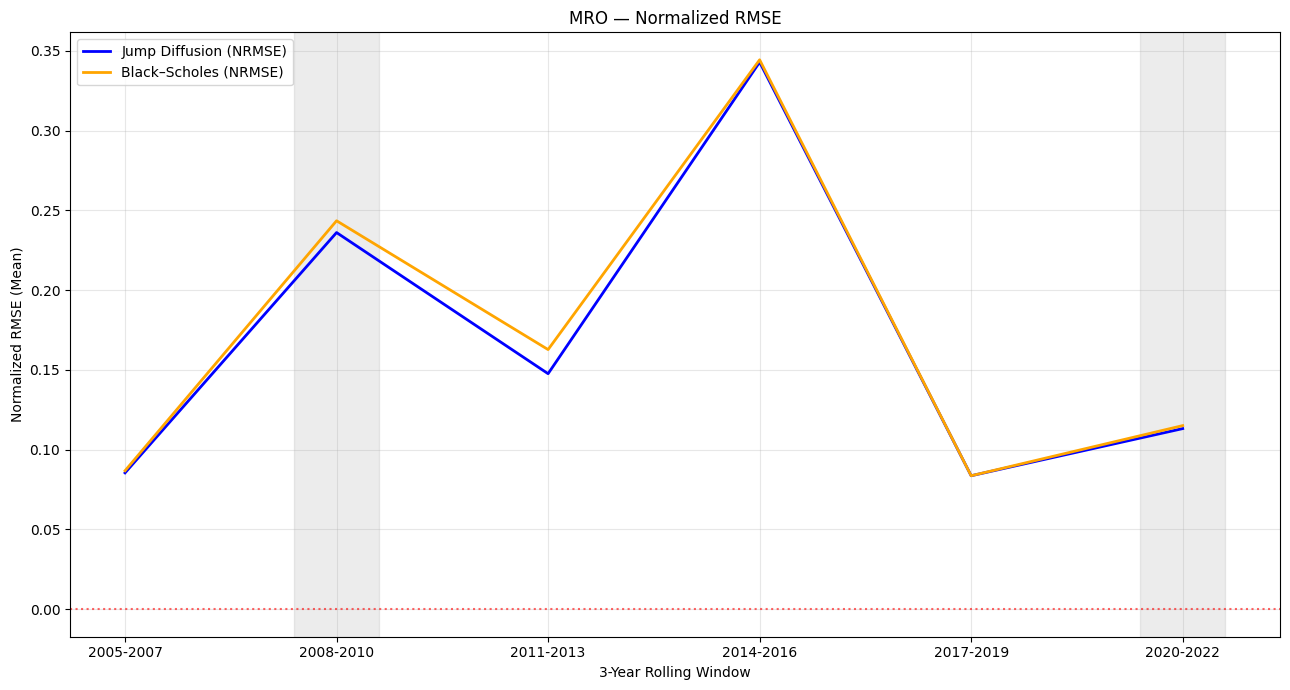

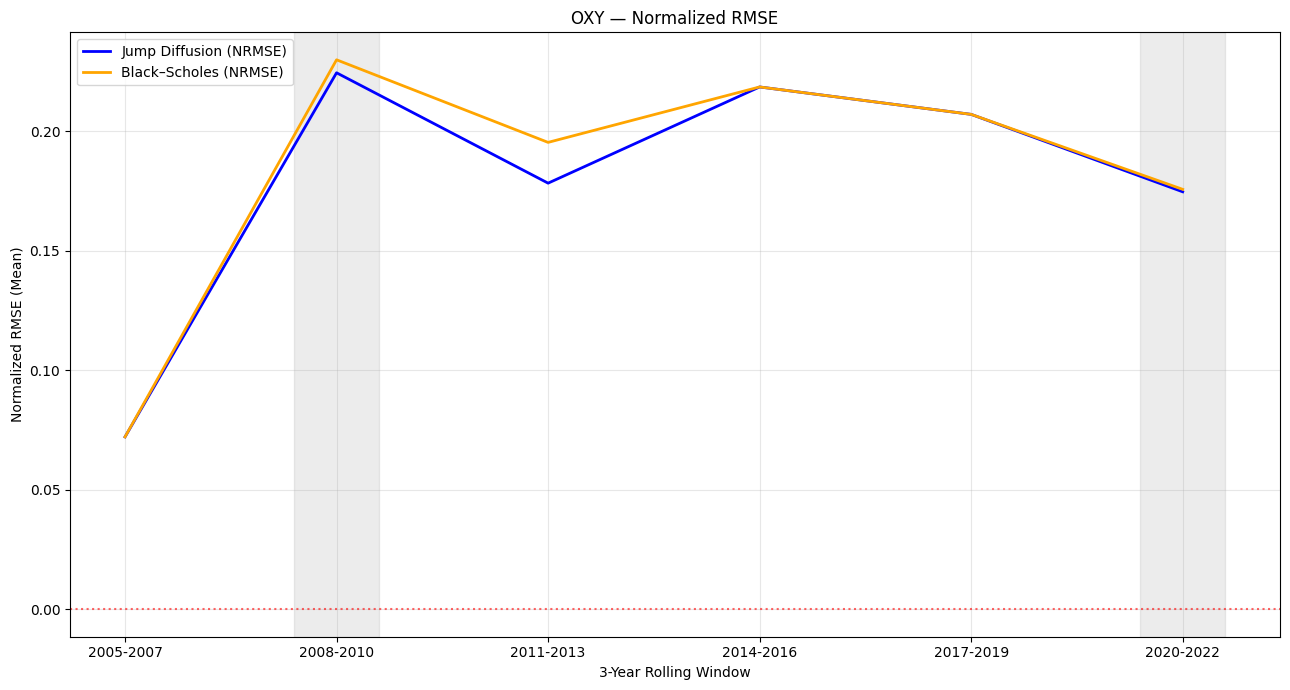

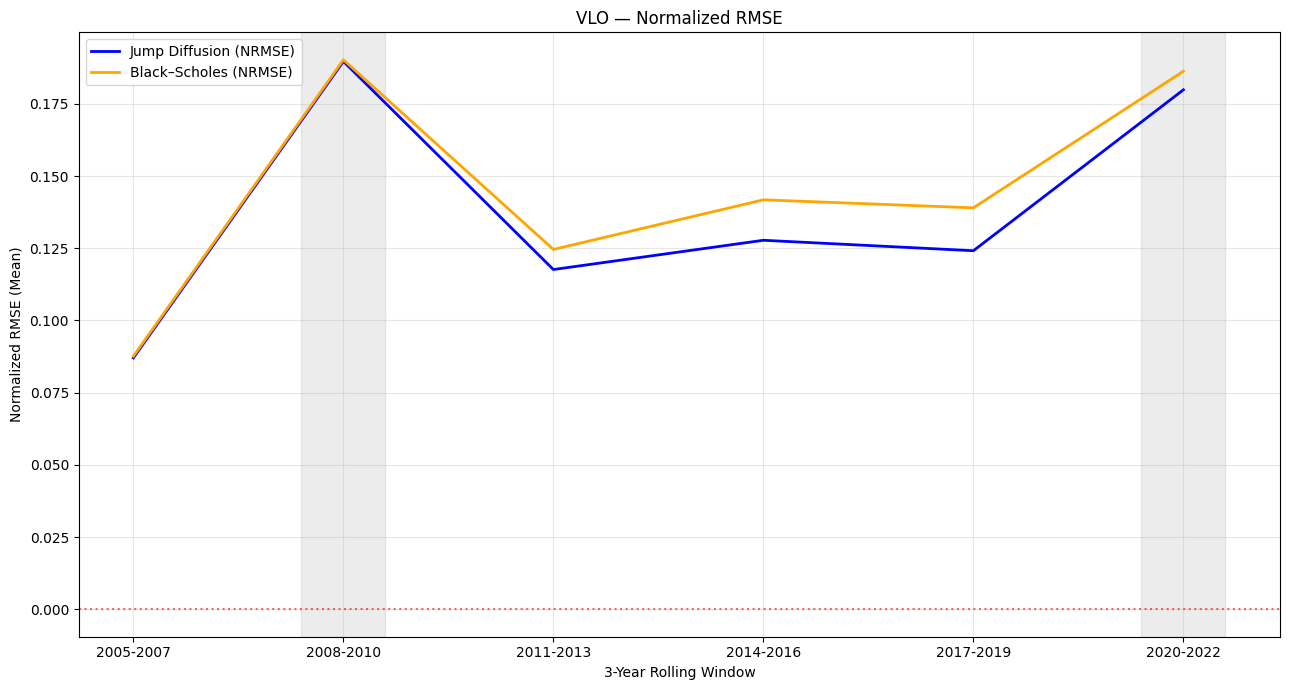

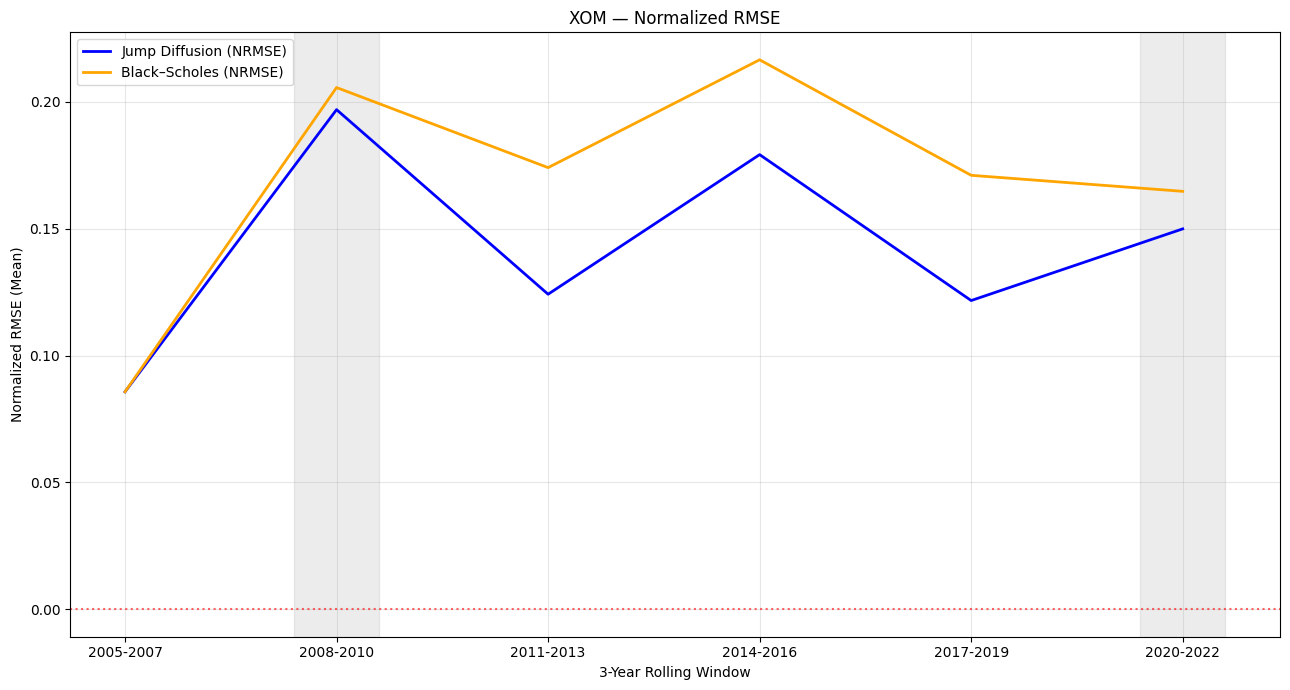

In [33]:
# Create window column in both original dataframes
stats_m_df["window"] = (
    stats_m_df["start_year"].astype(str) + "-" + stats_m_df["end_year"].astype(str)
)
stats_b_df["window"] = (
    stats_b_df["start_year"].astype(str) + "-" + stats_b_df["end_year"].astype(str)
)

# Define crisis windows
crisis_windows = ["2008-2010", "2020-2022"]

# Run loop for plotting NRMSE and relative performance per ticker
for t in tickers_array:
    # Filter dataframes per ticker
    df_m = stats_m_df[stats_m_df["ticker"] == t].copy()   # JD dataframe
    df_b = stats_b_df[stats_b_df["ticker"] == t].copy()   # BS dataframe

    # Reorder df_models according to JD window order
    windows = df_m["window"].tolist()
    x = range(len(windows))

    # Create figure and primary axis
    fig, ax1 = plt.subplots(figsize=(13, 7))

    # Plot NRMSE for both models (left y-axis)
    line1 = ax1.plot(
        x, df_m["nrmse_mean"],
        label="Jump Diffusion (NRMSE)",
        color="blue",
        linewidth=2
    )

    line2 = ax1.plot(
        x, df_b["nrmse_mean"],
        label="Black–Scholes (NRMSE)",
        color="orange",
        linewidth=2
    )
    
    # Set x-axis label
    ax1.set_xlabel("3-Year Rolling Window")
    ax1.set_xticks(list(x))
    ax1.set_xticklabels(windows)
    # Set left y-axis label
    ax1.set_ylabel("Normalized RMSE (Mean)")
    # Set grid
    ax1.grid(True, alpha=0.3)

    # Shade crisis periods on primary axis
    for cw in crisis_windows:
        if cw in windows:
            i = windows.index(cw)
            ax1.axvspan(
                i - 0.2, i + 0.2,
                color="gray",
                alpha=0.15,
                zorder=0
            )

    # Reference line at zero
    ax1.axhline(0, color="red", linestyle=":", alpha=0.6)

    # Set title and legend
    ax1.set_title(f"{t} — Normalized RMSE")

    # Combine legends from both axes
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc="upper left")

    # Set tight layout
    plt.tight_layout()

    # Save if required
    if save_plt:
        os.makedirs("rmse_time_series", exist_ok=True)
        filepath = f"rmse_time_series/rmse_time_series_{t}.png"
        plt.savefig(filepath, dpi=300, bbox_inches="tight")

    # Show plot
    plt.show()

## Plot λ Time Series per Ticker (Fig.10)

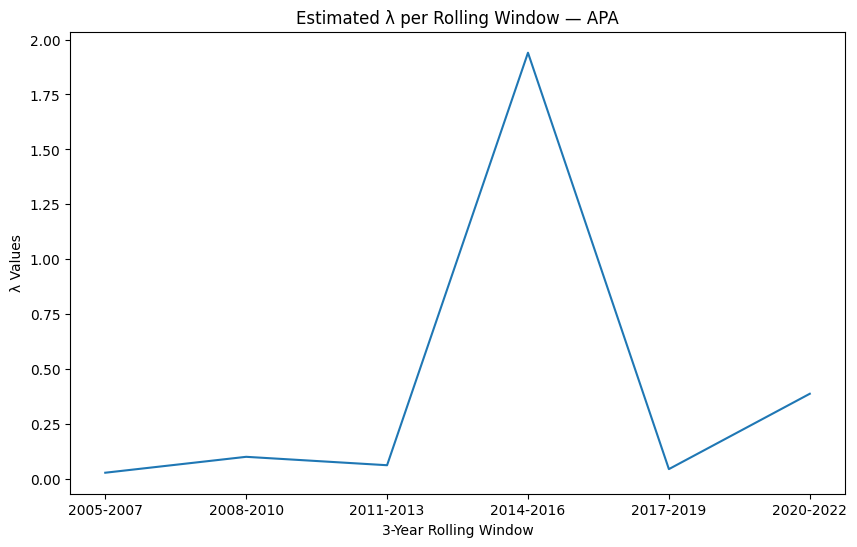

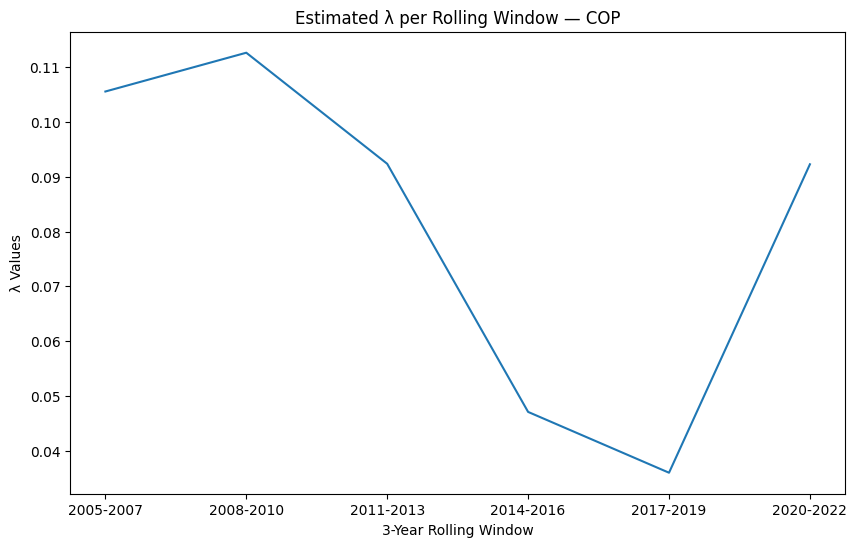

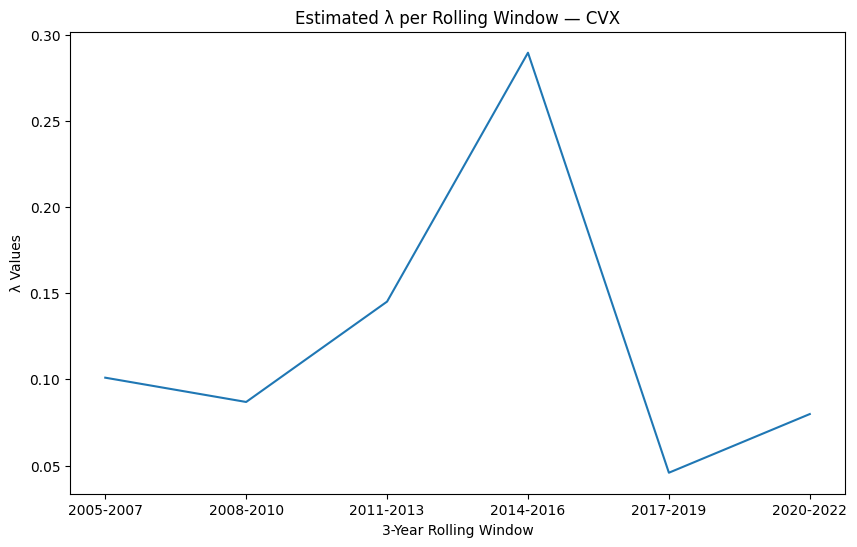

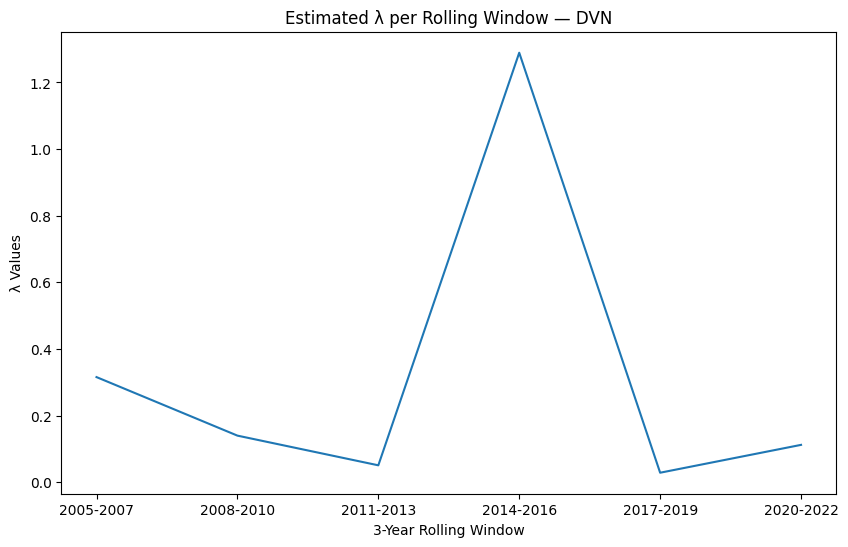

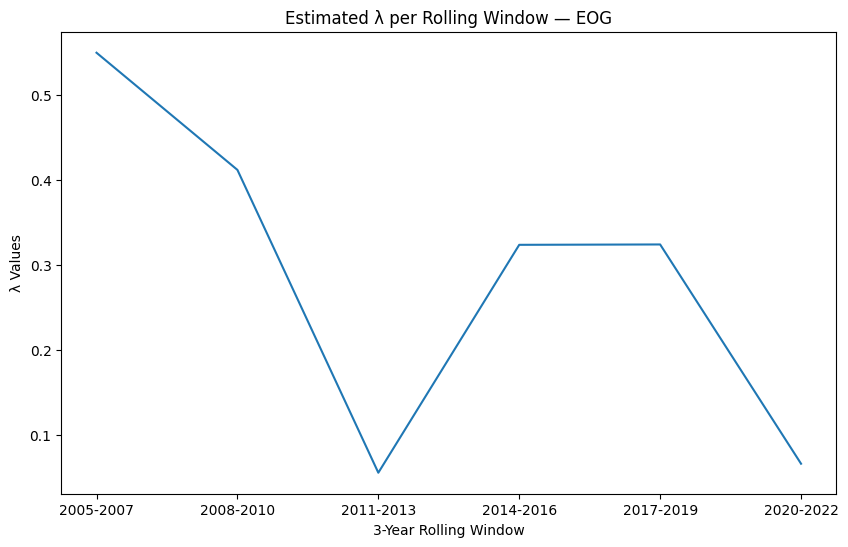

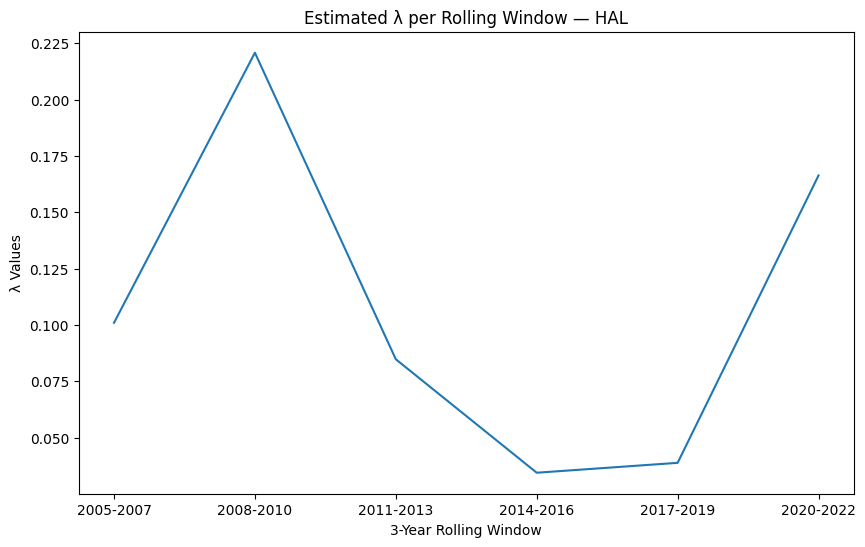

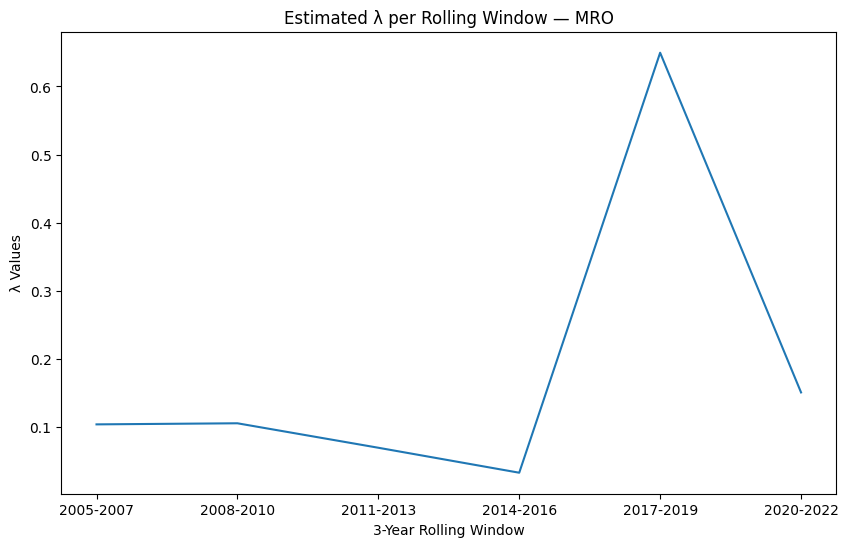

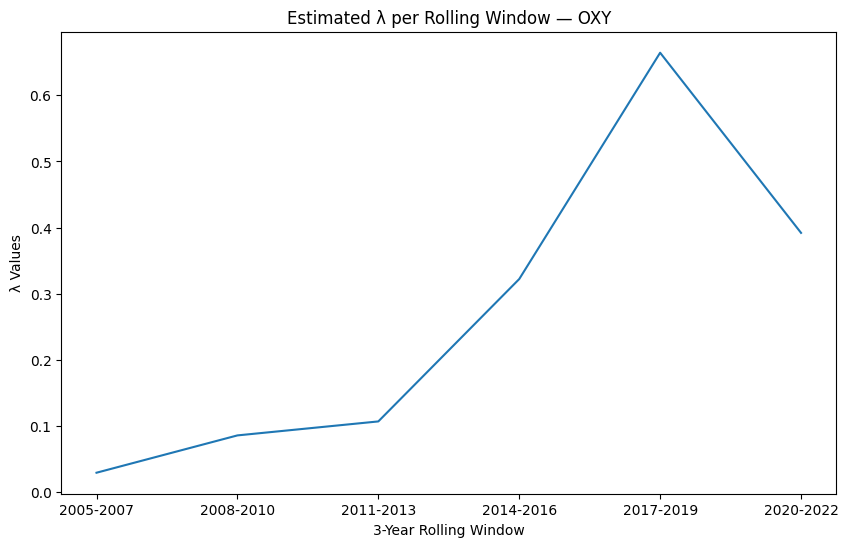

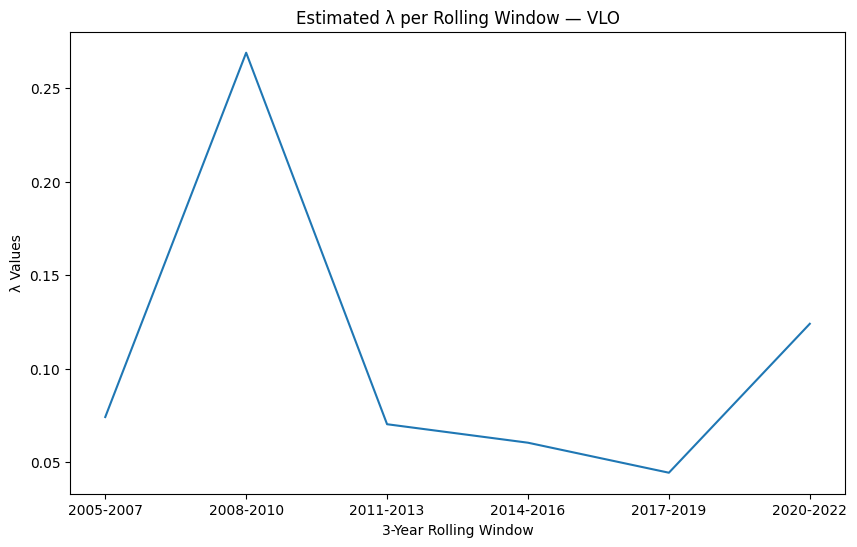

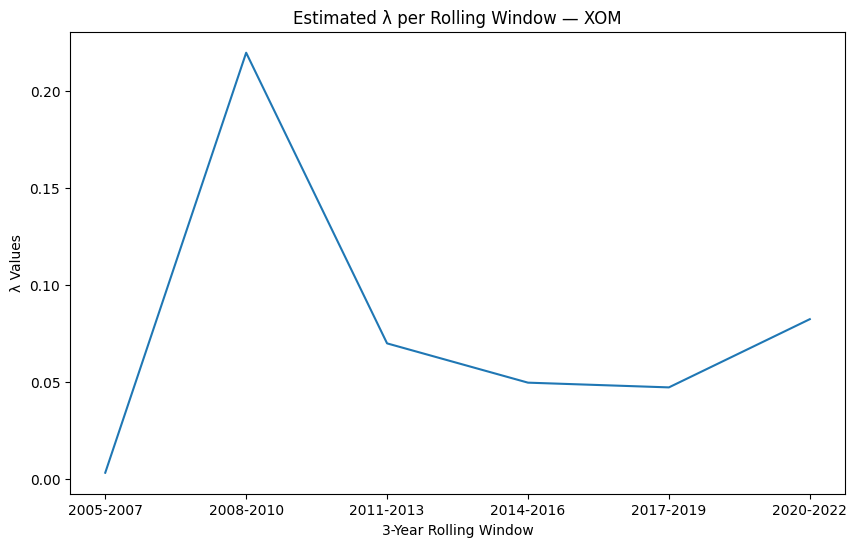

In [9]:
# Run loop per ticker to get line plot of lambda parameters
for t in tickers_array:
    # Filter for one dataframe per ticker
    df = param_m_summary[param_m_summary["ticker"] == t].copy()
    
    # Plot lambda parameters
    plt.figure(figsize=(10,6))
    plt.plot(df["window"], df["lam"])
    
    # Set title
    plt.title(f"Estimated λ per Rolling Window — {t}")
    
    # Set axis labels
    plt.xlabel("3-Year Rolling Window")
    plt.ylabel("λ Values")
    
    # Save if required
    if save_plt:
        # Create directory
        os.makedirs("lambda_plots", exist_ok=True)
        # Save figure as png in directory
        filepath = f"lambda_plots/lambda_plots_{t}"
        plt.savefig(filepath, dpi=300, bbox_inches="tight")

    # Show plot 
    plt.show()

## Plot Median % Error vs. Moneyness for Each Model (Fig. 11)

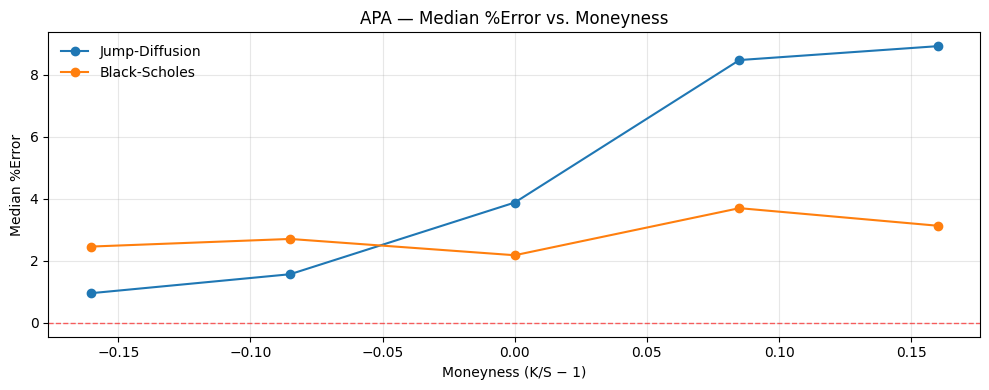

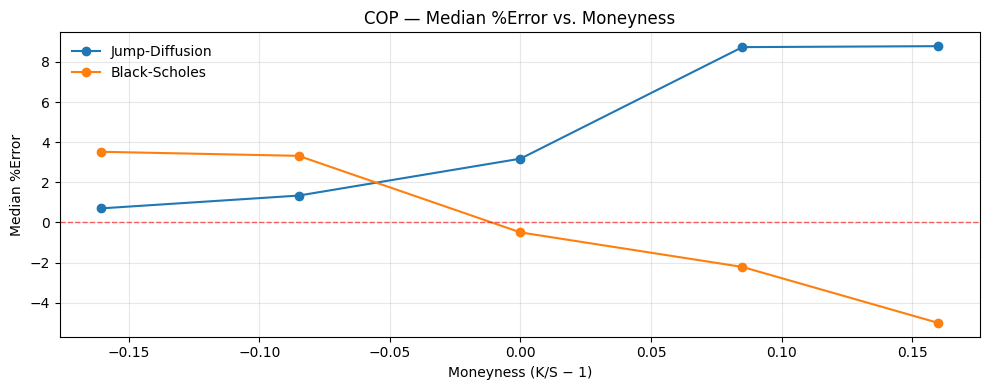

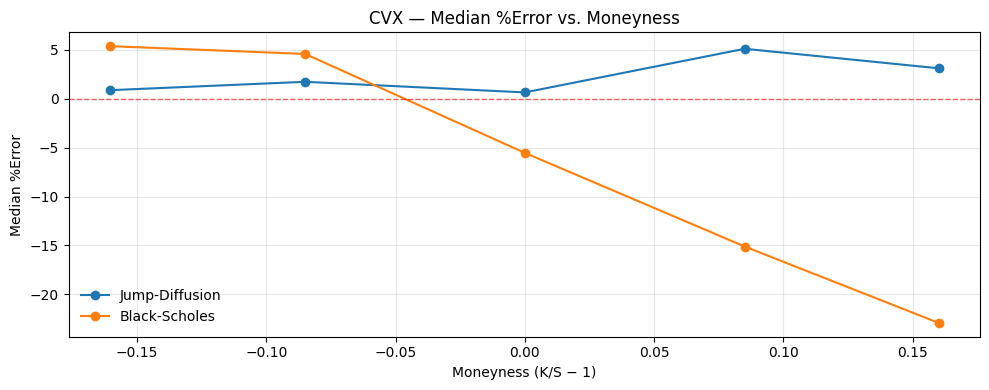

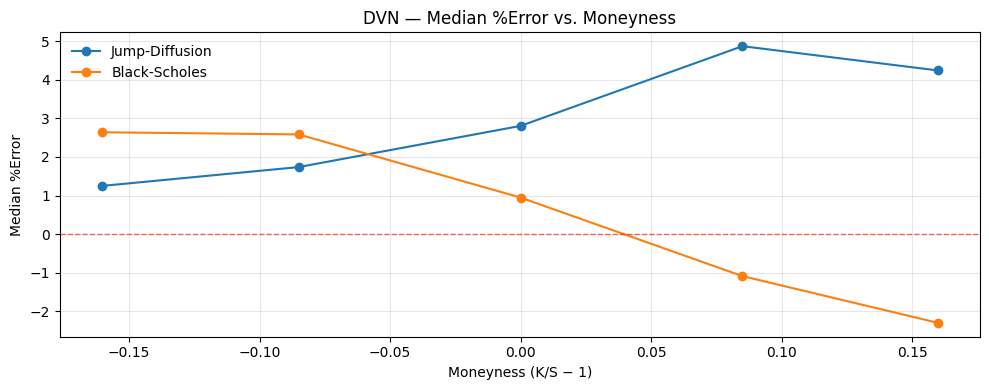

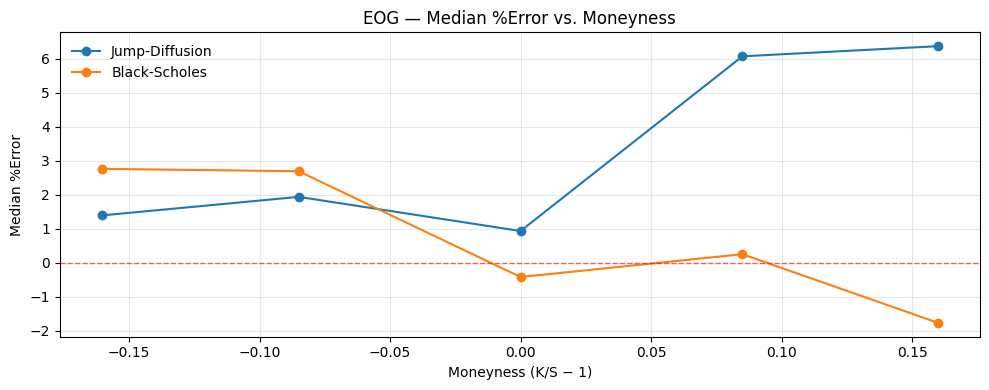

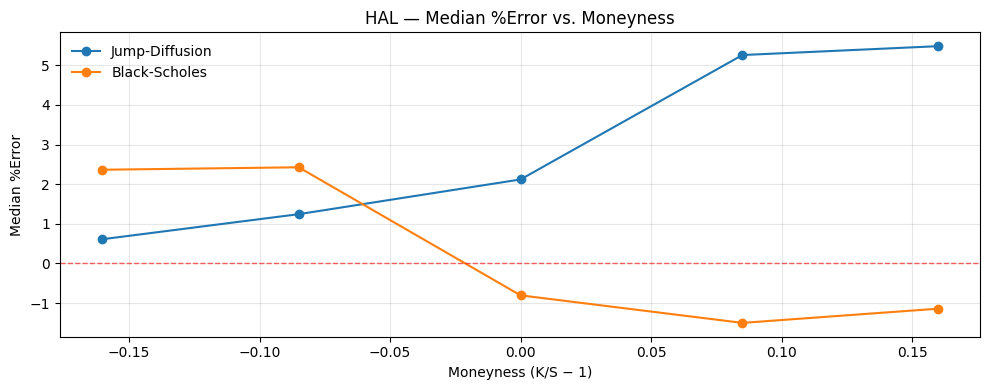

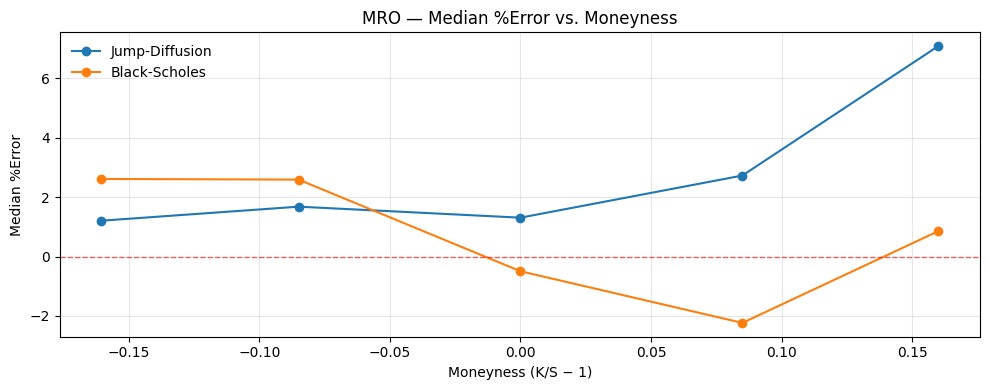

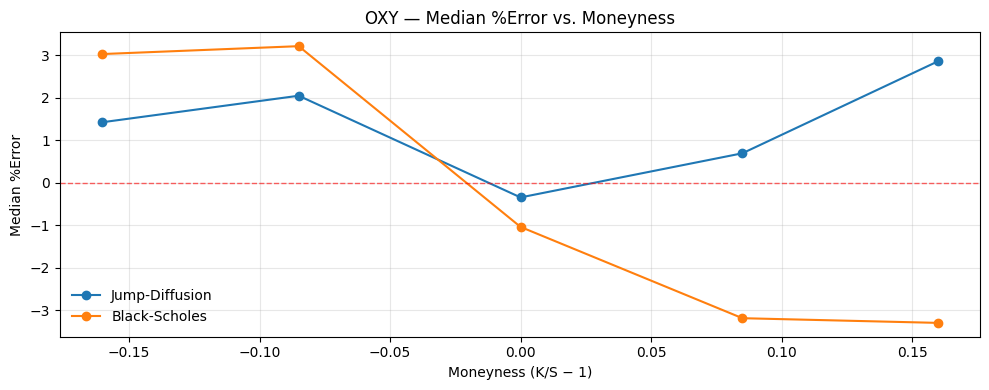

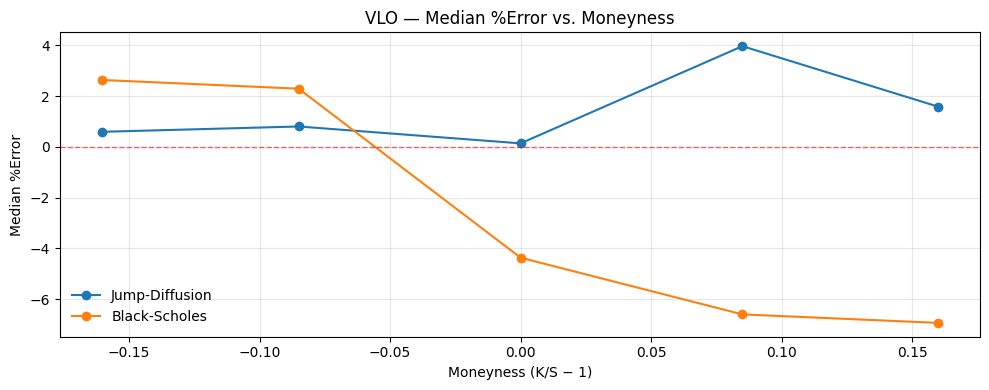

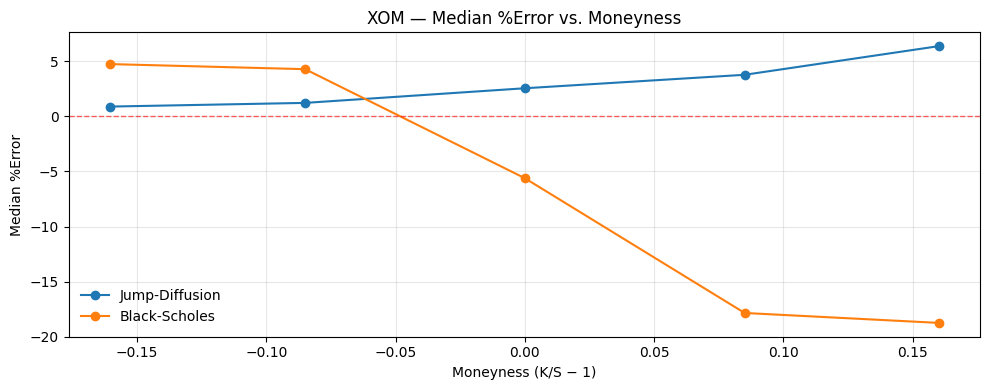

In [10]:
# Set both modeled prices dataframe together
models_money = [("Jump-Diffusion", price_m_df), ("Black-Scholes", price_b_df)]

# Set helper function to plot %error vs. moneyness
def plot_error_money(
    models_money,
    tickers=None,
    save=True,
    bins=None,
    figsize=(10, 4),
    save_dir="error_vs_moneyness"
):
    """
    Return plots of median %error vs. moneyness 
    and saves them as png in a file.
    
    Given:
    - models_money : dictionary of models with BS and jump-diffusion prices
    - tickers      : array of tickers. Set tickers list if none.
    - bins         : array of bins. Set bins list if none.
    - save_dir     : file name
    """

    # Set moneyness bins
    if bins is None:
        bins = [-0.20, -0.12, -0.05, 0.05, 0.12, 0.20]

    # Set tickers array
    if tickers is None:
        tickers = sorted(
            models_money[0][1]["ticker"].dropna().unique().tolist()
        )

    figs = {}

    # Run loop per ticker
    for ticker in tickers:
        fig, ax = plt.subplots(1, 1, figsize=figsize)

        # Run loop per model
        for model_name, df_model in models_money:
            plot_df = df_model.loc[
                df_model["ticker"] == ticker,
                ["%moneyness", "%error"]
            ].dropna().copy()

            if plot_df.empty:
                continue

            # Define moneyness bins
            plot_df["moneyness_bin"] = pd.cut(
                plot_df["%moneyness"],
                bins=bins,
                include_lowest=True,
                right=True
            )

            # Set median %error by bin
            smile = (
                plot_df.groupby("moneyness_bin", observed=True)["%error"]
                       .median()
                       .reset_index(name="med_error")
            )

            # Set bin midpoints
            smile["moneyness_mid"] = smile["moneyness_bin"].apply(
                lambda iv: (iv.left + iv.right) / 2.0
            )

            # Drop NA values
            smile = smile.dropna(subset=["med_error", "moneyness_mid"])

            # Plot
            ax.plot(
                smile["moneyness_mid"],
                smile["med_error"],
                marker="o",
                linewidth=1.5,
                label=model_name
            )

        # Set horizontal line
        ax.axhline(0, linestyle="--", linewidth=1.0, alpha=0.6, color="red")

        # Set labels
        ax.set_title(f"{ticker} — Median %Error vs. Moneyness")
        ax.set_xlabel("Moneyness (K/S − 1)")
        ax.set_ylabel("Median %Error")
        ax.grid(True, alpha=0.3)
        ax.legend(frameon=False)

        fig.tight_layout()
        
        if save:
            # Create directory
            os.makedirs(save_dir, exist_ok=True)
            # Save figure as png in directory
            filepath = f"{save_dir}/error_vs_moneyness_{ticker}.png"
            fig.savefig(filepath, dpi=300, bbox_inches="tight")

        figs[ticker] = fig

        plt.show()
        plt.close(fig) 

    return figs

# Plot
figs = plot_error_money(
    models_money=models_money,
    tickers=tickers_array,
    save=save_plt
)

## Set Moneyness Categories for Analysis

In [11]:
# Copy jump-diffusion modeled prices
merton_money = price_m_df.copy()

# Copy Black-Scholes modeled prices
bs_money = price_b_df.copy()

# Set moneyness categories
merton_money["mny_cat"] = pd.cut(
    merton_money["%moneyness"],
    bins=[-np.inf, -0.05, 0.05, np.inf],
    labels=["ITM", "ATM", "OTM"],
    right=True
)

bs_money["mny_cat"] = pd.cut(
    bs_money["%moneyness"],
    bins=[-np.inf, -0.05, 0.05, np.inf],
    labels=["ITM", "ATM", "OTM"],
    right=True
)

## Plot Median %Error vs. Time-to-Maturity per Moneyness for Each Model (Fig. 12)

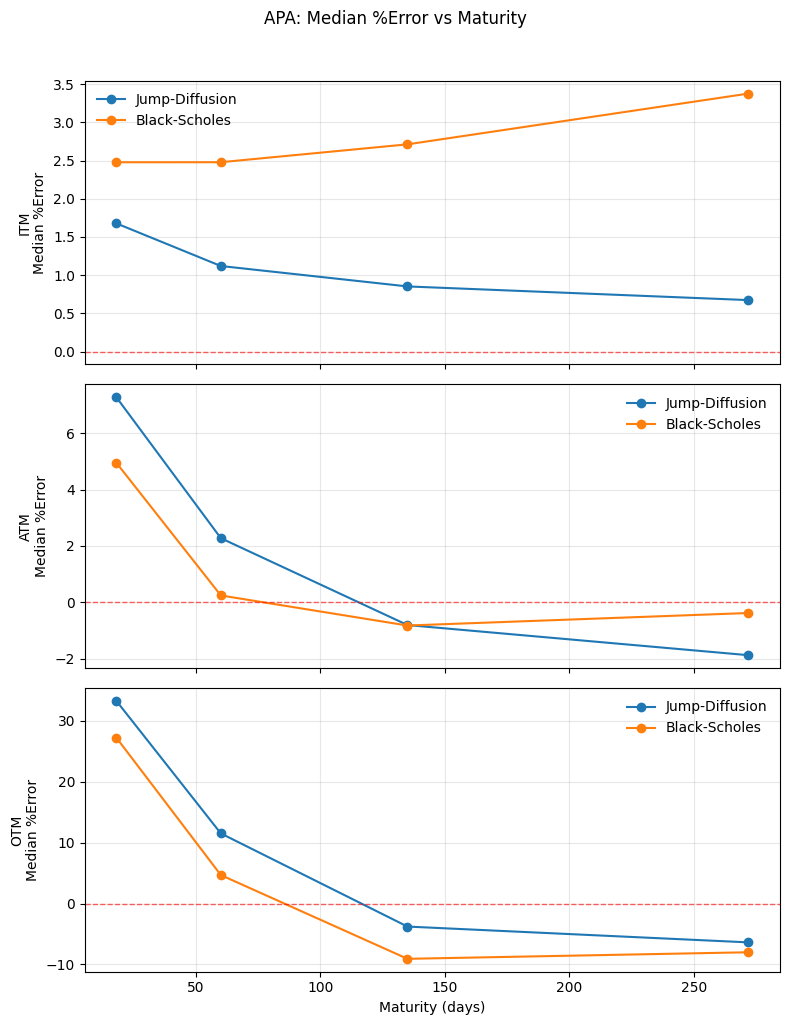

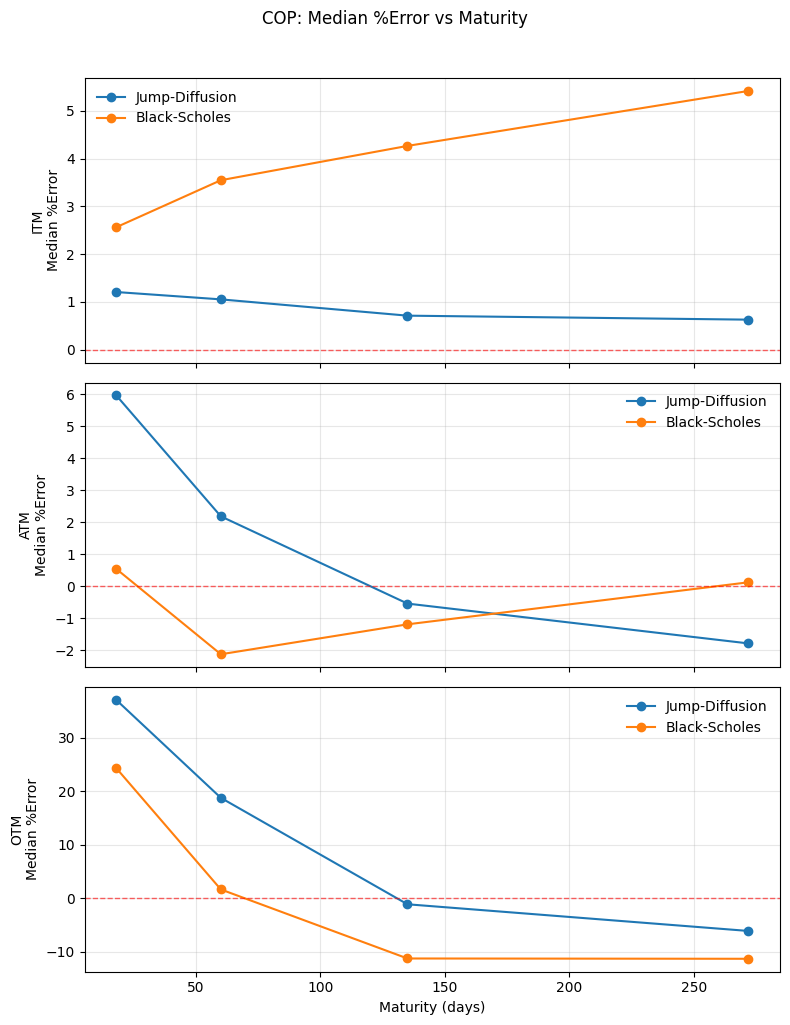

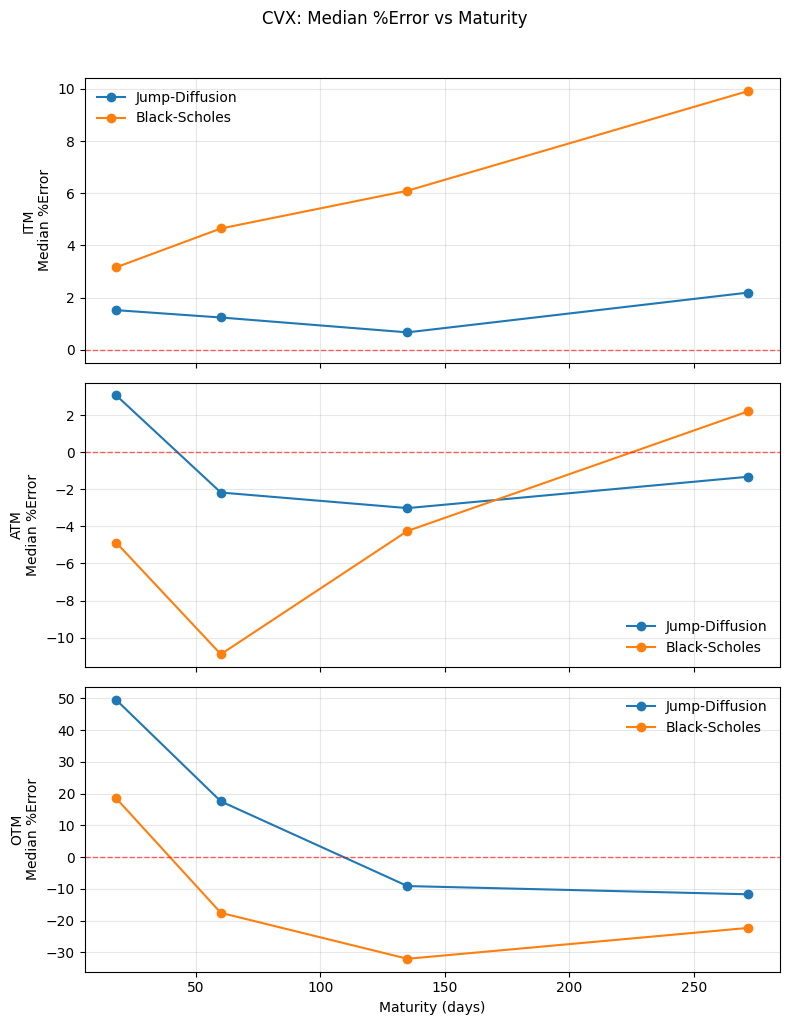

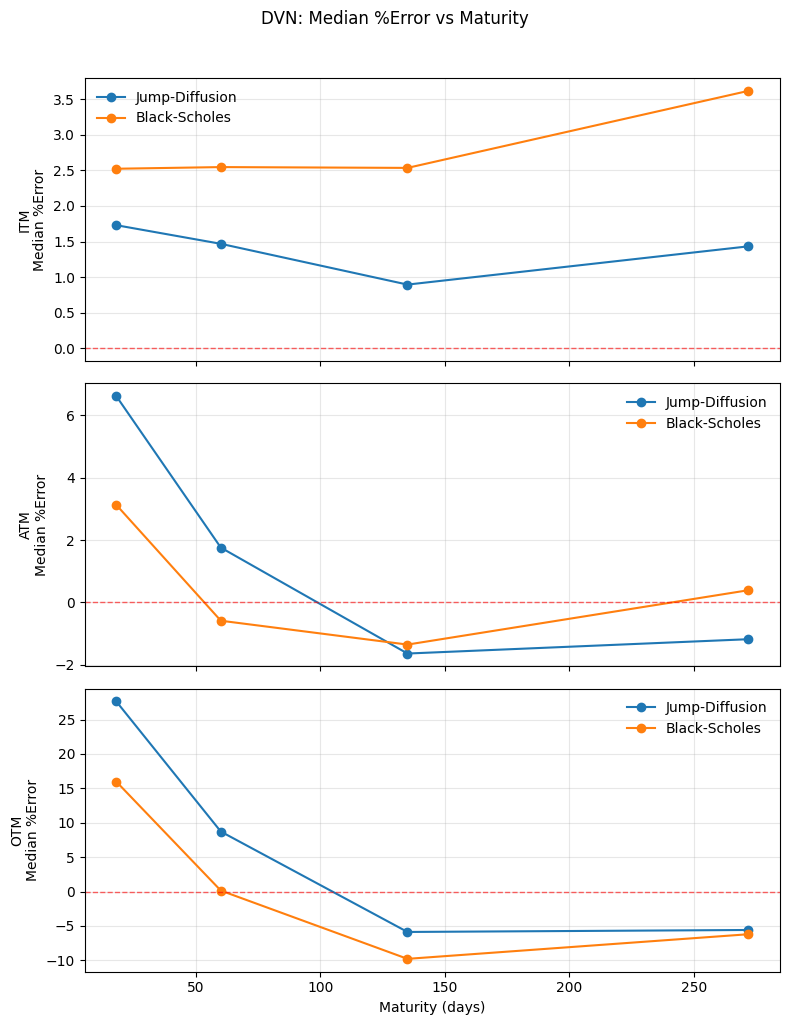

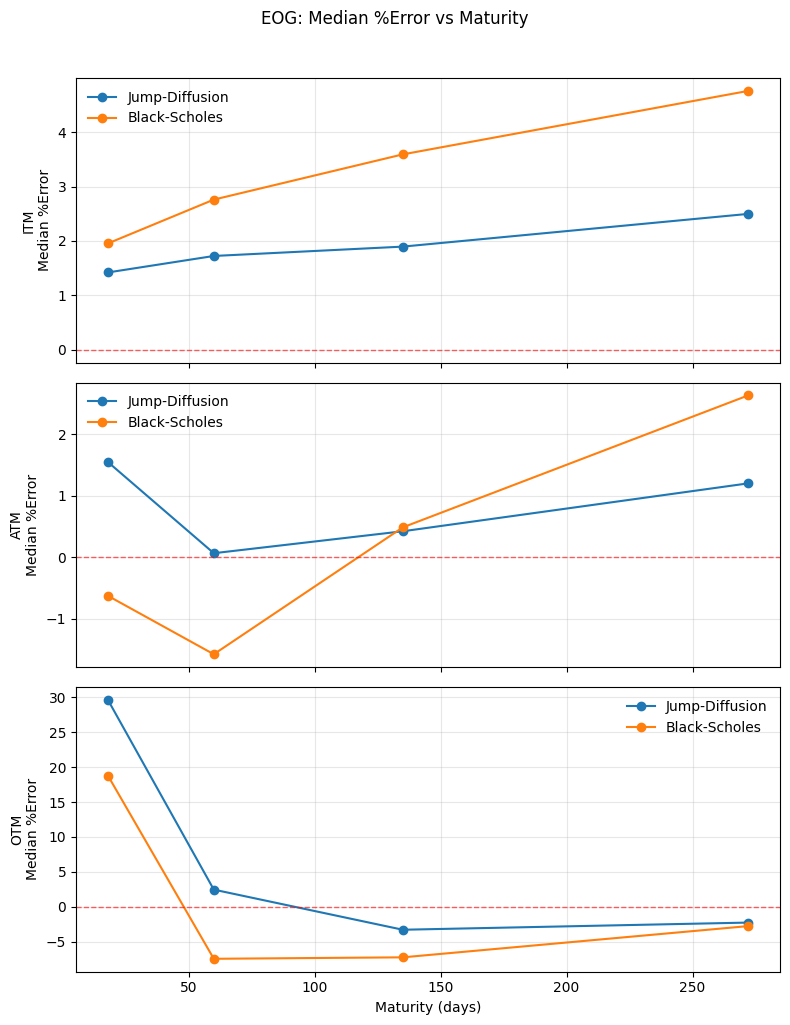

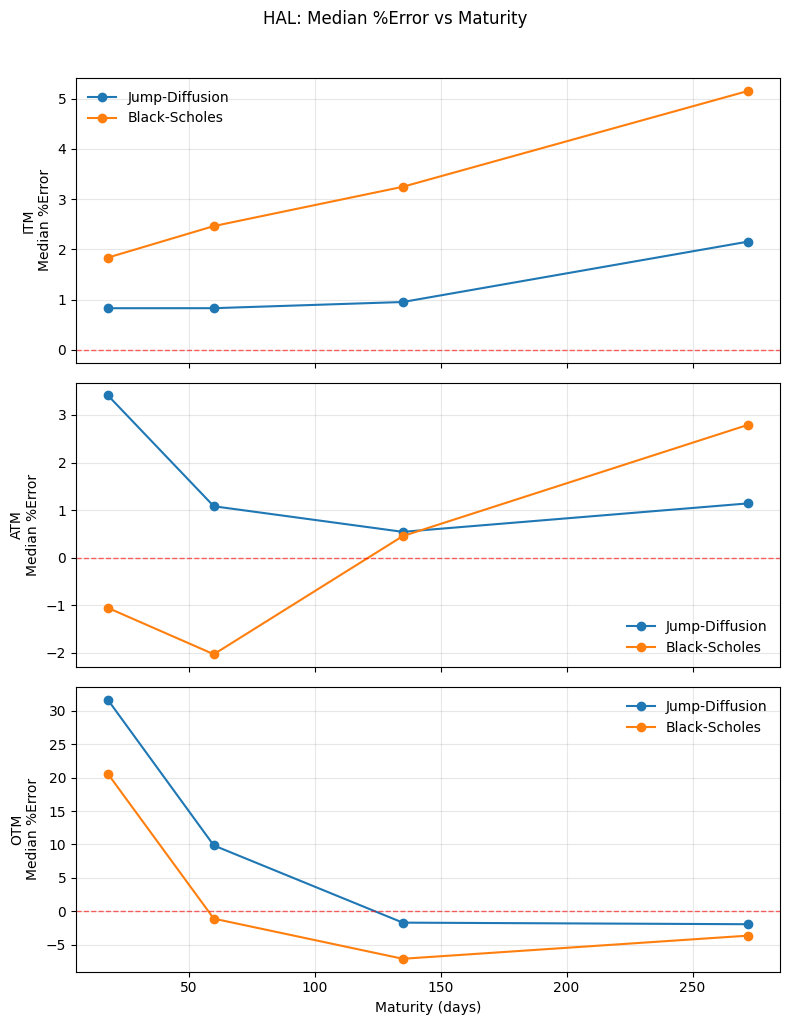

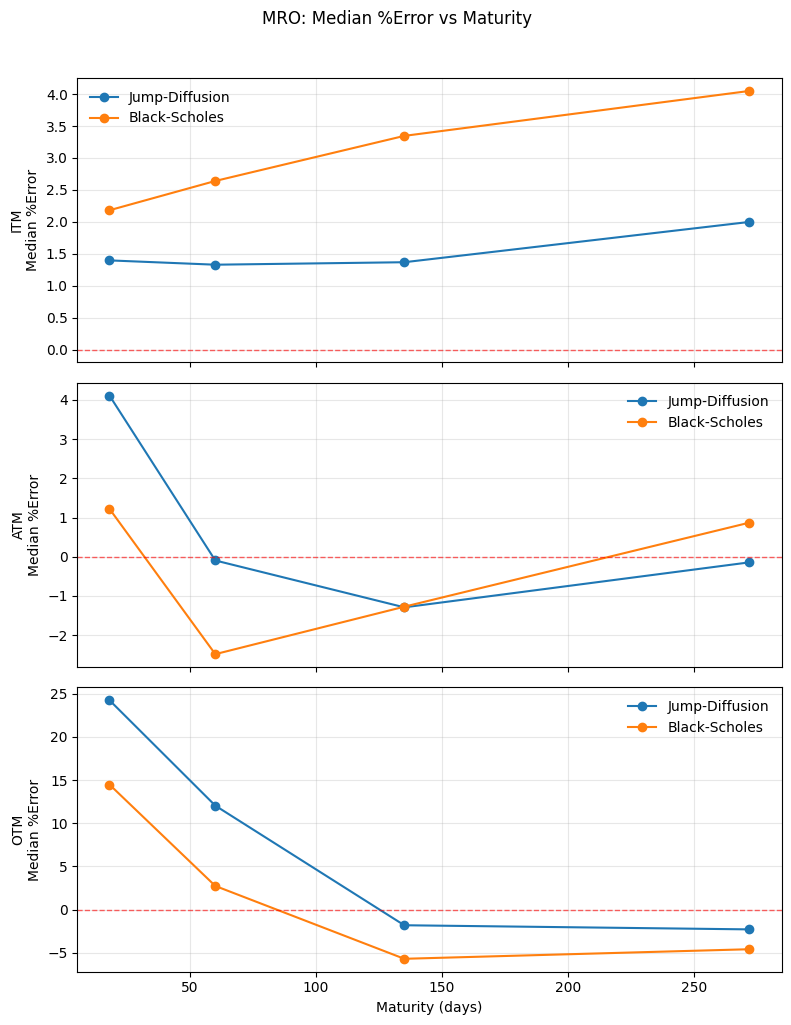

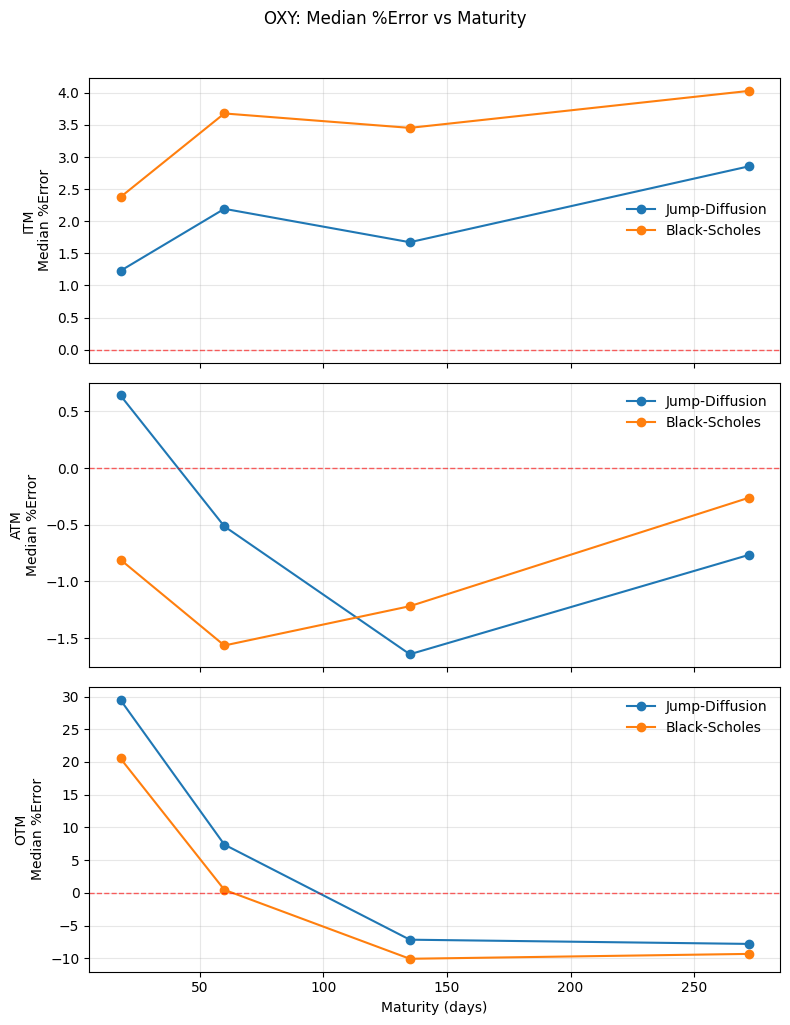

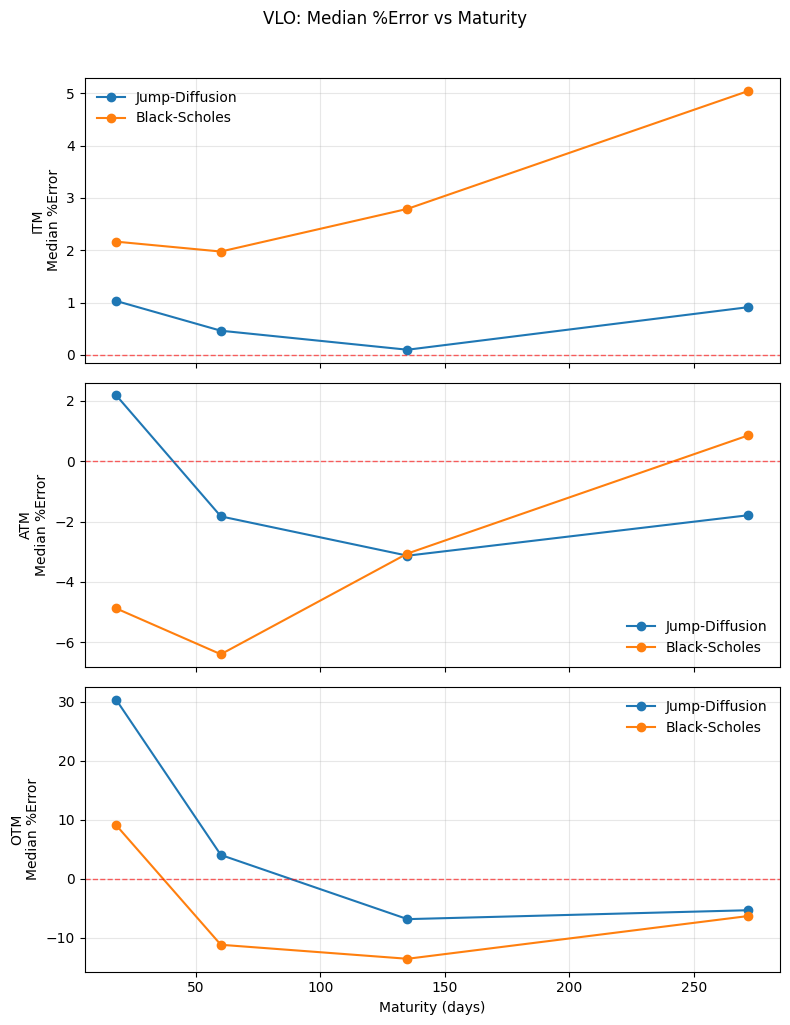

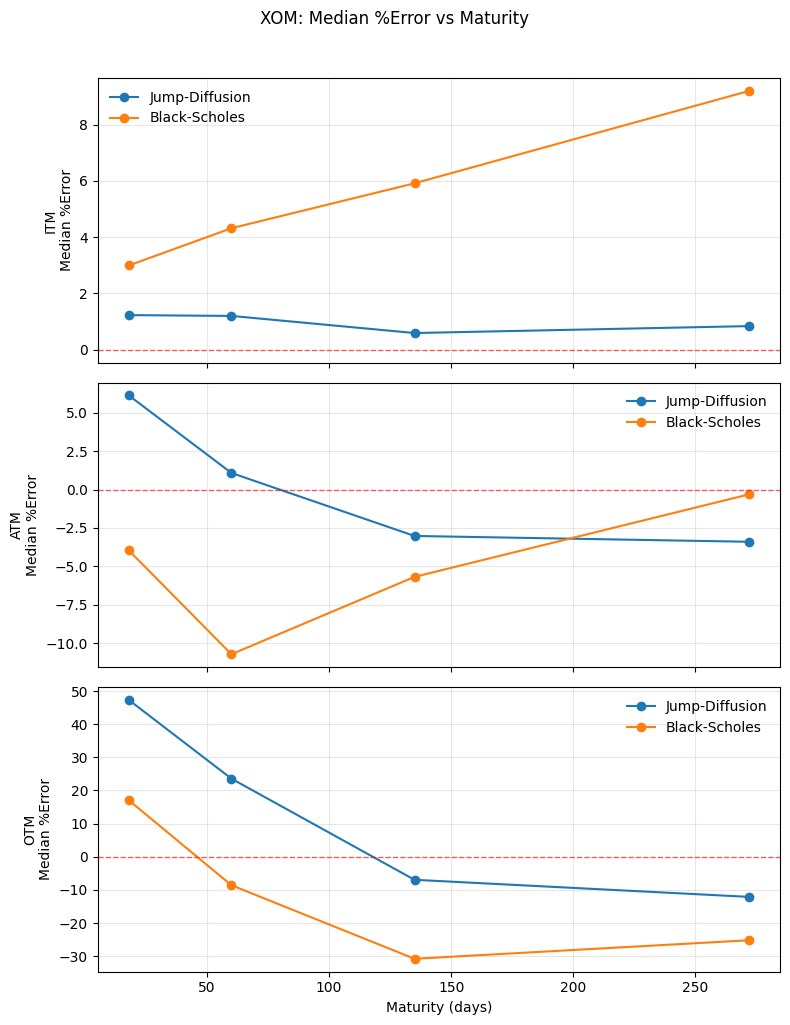

In [12]:
# Set helper function to get maturity bins
def bin_maturity_by_ticker(df, bins=[7, 30, 90, 180, 365], cats=("ITM", "ATM", "OTM")):
    """
    Returns a dataframe binned by maturity for each 
    moneyness categories.
    
    Given:
    - df   : dataframe input
    - bins : list of bins for maturity
    - cats : moneyness categories
    """
    
    # Drop NA values
    df = df.dropna(subset=["ticker", "maturity_days", "mny_cat", "%moneyness", "%error"]).copy()
    # Ensure moneyness categories in the dataframe
    df = df[df["mny_cat"].isin(cats)].copy()
    
    # Set list to store results
    out = []
    
    # Run loop to bin maturity over ticker and moneyness categories
    for (t, cat), sub in df.groupby(["ticker", "mny_cat"], observed=True):
        if sub.shape[0] < 3:
            continue
        
        sub = sub.copy()
        
        # Create bins over maturity
        sub["mat_bin"] = pd.cut(sub["maturity_days"], bins=bins, include_lowest=True)
        
        agg = (
            sub.groupby("mat_bin", observed=True)
            .agg(med_error=("%error", "median"))
            .reset_index()
        )
        
        # Set bin mid-point
        agg["mat_mid"] = agg["mat_bin"].apply(lambda x: (x.left + x.right) / 2).astype(int)
        # Set lower bin point
        agg["mat_left"] = agg["mat_bin"].apply(lambda x: (x.left)).astype(int)
        # Set higher bin point
        agg["mat_righ"] = agg["mat_bin"].apply(lambda x: (x.right)).astype(int)
        # Set ticker evaluated
        agg["ticker"] = t
        # Set moneyness evaluated
        agg["mny_cat"] = cat
        # Append data
        out.append(agg)
    
    # Return dataframe
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()

# Create maturity bins for each modeled prices using helper function
mat_merton = bin_maturity_by_ticker(merton_money)
mat_bs     = bin_maturity_by_ticker(bs_money)

# Set moneyness categories for loop
cats = ["ITM", "ATM", "OTM"]

# Set both modeled prices dataframe together
models_mat = [("Jump-Diffusion", mat_merton), ("Black-Scholes", mat_bs)]

# Set helper function to plot median %error vs. maturity
def plot_mat_panels(ticker, save=True):
    """
    Returns plots of median %error vs maturity per ticker,
    with both models overlaid on the same axis (one column).
    """

    # Define subplot features
    fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

    # Ensure axes is always indexable
    if len(cats) == 1:
        axes = np.array([axes])
    
    # Run loop over moneyness categories
    for i, cat in enumerate(cats):
        ax = axes[i]

        # Plot both models on same axis
        for model_name, bdf in models_mat:
            plot_df = bdf[(bdf["ticker"] == ticker) & (bdf["mny_cat"] == cat)].copy()

            if plot_df.empty:
                continue

            ax.plot(
                plot_df["mat_mid"],
                plot_df["med_error"],
                marker="o",
                linestyle="-",
                linewidth=1.5,
                label=model_name
            )
            plotted_any = True

        # Set horizontal line
        ax.axhline(0, linestyle="--", linewidth=1.0, alpha=0.6, color="red")

        # Set labels
        ax.set_ylabel(f"{cat}\nMedian %Error")
        ax.grid(alpha=0.3)
        ax.legend(frameon=False)

    axes[-1].set_xlabel("Maturity (days)")

    fig.suptitle(f"{ticker}: Median %Error vs Maturity", y=1.02)
    fig.tight_layout()
    
    # Save if required
    if save:
        # Create directory
        os.makedirs("error_vs_maturity", exist_ok=True)
        # Save figure as png directory
        filepath = f"error_vs_maturity/error_vs_maturity_{ticker}.png"
        fig.savefig(filepath, dpi=300, bbox_inches="tight")
    
    # Show plots
    plt.show()

# Run loop over ticker to generate plots
for t in tickers_array:
    plot_mat_panels(t, save=save_plt)